<a href="https://colab.research.google.com/github/Sameekshaingole/fraud-detection-federated-learning/blob/main/notebooks/Baseline_model.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

BASELINE MODEL (CENTRALIZED)

 Handles:

Class imbalance
Proper evaluation
Threshold tuning
Overfitting control
Feature importance

In [2]:
# =========================
# BASELINE MODEL
# =========================
from google.colab import drive
drive.mount('/content/drive')


Mounted at /content/drive


In [3]:
import numpy as np
import pickle
import time
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (classification_report,
                             confusion_matrix,
                             roc_auc_score,
                             accuracy_score,
                             precision_score,
                             recall_score,
                             f1_score)
from sklearn.utils.class_weight import compute_class_weight
import matplotlib.pyplot as plt
import seaborn as sns

print("All libraries imported!")

All libraries imported!


In [4]:
print("Loading data from Drive...")

X_train = np.load('/content/drive/MyDrive/fraud_detection_project/X_train.npy')
X_test  = np.load('/content/drive/MyDrive/fraud_detection_project/X_test.npy')
y_train = np.load('/content/drive/MyDrive/fraud_detection_project/y_train.npy')
y_test  = np.load('/content/drive/MyDrive/fraud_detection_project/y_test.npy')

print("X_train shape:", X_train.shape)
print("X_test shape :", X_test.shape)
print("y_train shape:", y_train.shape)
print("y_test shape :", y_test.shape)
print("Fraud in train:", int(y_train.sum()))
print("Fraud in test :", int(y_test.sum()))
print("Data loaded successfully!")

Loading data from Drive...
X_train shape: (472432, 224)
X_test shape : (118108, 224)
y_train shape: (472432,)
y_test shape : (118108,)
Fraud in train: 16530
Fraud in test : 4133
Data loaded successfully!


In [13]:
print("Training Random Forest...")
print("Please wait 10-15 minutes...")

start = time.time()

rf_model = RandomForestClassifier(
    n_estimators=100,
    class_weight='balanced',
    random_state=42,
    n_jobs=-1
)

rf_model.fit(X_train, y_train)

training_time = time.time() - start
print(f"Training done in {round(training_time, 2)} seconds!")

Training Random Forest...
Please wait 10-15 minutes...
Training done in 288.14 seconds!


In [14]:
y_pred = rf_model.predict(X_test)
y_prob = rf_model.predict_proba(X_test)[:, 1]

accuracy  = accuracy_score(y_test, y_pred)
precision = precision_score(y_test, y_pred)
recall    = recall_score(y_test, y_pred)
f1        = f1_score(y_test, y_pred)
roc_auc   = roc_auc_score(y_test, y_prob)

print("=" * 50)
print("   RANDOM FOREST BASELINE RESULTS")
print("=" * 50)
print(f"Accuracy  : {round(accuracy,  4)}")
print(f"Precision : {round(precision, 4)}")
print(f"Recall    : {round(recall,    4)}")
print(f"F1 Score  : {round(f1,        4)}")
print(f"ROC-AUC   : {round(roc_auc,   4)}")
print(f"Train Time: {round(training_time, 2)} seconds")
print("=" * 50)
print(f"Predicted fraud: {y_pred.sum()}")
print(f"Actual fraud   : {int(y_test.sum())}")
print(classification_report(y_test, y_pred,
      target_names=['Not Fraud', 'Fraud']))

   RANDOM FOREST BASELINE RESULTS
Accuracy  : 0.9791
Precision : 0.9296
Recall    : 0.4348
F1 Score  : 0.5925
ROC-AUC   : 0.9349
Train Time: 288.14 seconds
Predicted fraud: 1933
Actual fraud   : 4133
              precision    recall  f1-score   support

   Not Fraud       0.98      1.00      0.99    113975
       Fraud       0.93      0.43      0.59      4133

    accuracy                           0.98    118108
   macro avg       0.95      0.72      0.79    118108
weighted avg       0.98      0.98      0.98    118108



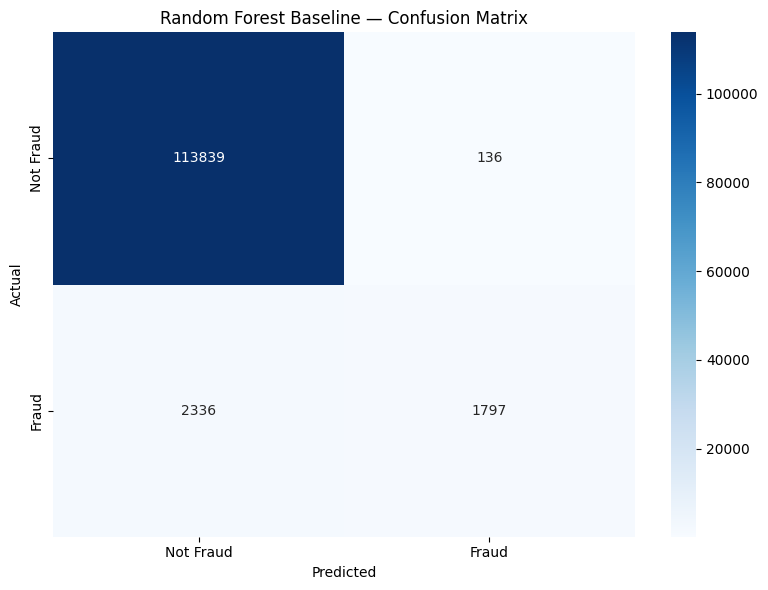

Confusion matrix saved!


In [15]:
cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Not Fraud', 'Fraud'],
            yticklabels=['Not Fraud', 'Fraud'])

plt.title('Random Forest Baseline — Confusion Matrix')
plt.ylabel('Actual')
plt.xlabel('Predicted')
plt.tight_layout()
plt.savefig('/content/drive/MyDrive/fraud_detection_project/baseline_confusion_matrix.png')
plt.show()
print("Confusion matrix saved!")

In [16]:
with open('/content/drive/MyDrive/fraud_detection_project/baseline_model.pkl', 'wb') as f:
    pickle.dump(rf_model, f)
print("baseline_model.pkl saved!")

results_text = f"""
BASELINE MODEL RESULTS
======================
Model      : Random Forest (100 trees)
Dataset    : IEEE-CIS Fraud Detection
Train size : {X_train.shape[0]}
Test size  : {X_test.shape[0]}

Accuracy   : {round(accuracy,  4)}
Precision  : {round(precision, 4)}
Recall     : {round(recall,    4)}
F1 Score   : {round(f1,        4)}
ROC-AUC    : {round(roc_auc,   4)}
Train Time : {round(training_time, 2)} seconds

Predicted fraud : {y_pred.sum()}
Actual fraud    : {int(y_test.sum())}
"""

with open('/content/drive/MyDrive/fraud_detection_project/baseline_results.txt', 'w') as f:
    f.write(results_text)

print("baseline_results.txt saved!")
print("Baseline model 100% complete!")

baseline_model.pkl saved!
baseline_results.txt saved!
Baseline model 100% complete!
